# SECOM process-monitoring companion

**Exploratory validation:** sensor selection uses labels from the full dataset before the train/test split. Reported model scores therefore are not unbiased holdout estimates. Imputation and scaling are train-only, but feature selection also needs to move inside training folds for independent validation. No engineering specification limits or confirmed physical root cause are available.


In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
SECOM_DIR = PROJECT_ROOT / "secom"

X = pd.read_csv(
    SECOM_DIR / "secom.data",
    sep=r"\s+",
    header=None,
    na_values="NaN",
)

labels = pd.read_csv(
    SECOM_DIR / "secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["Label", "Timestamp"],
    engine="c",
    quotechar='"',
)

labels["Timestamp"] = pd.to_datetime(
    labels["Timestamp"],
    format="%d/%m/%Y %H:%M:%S",
)

X.columns = [f"Sensor_{i:03d}" for i in range(1, X.shape[1] + 1)]

secom = X.copy()
secom.insert(0, "Timestamp", labels["Timestamp"])
secom.insert(0, "Label", labels["Label"])
secom["Failed"] = secom["Label"].eq(1)

print("Sensor data shape:", X.shape)
print("Combined data shape:", secom.shape)
print(secom["Failed"].value_counts())
print(secom.head())

Sensor data shape: (1567, 590)
Combined data shape: (1567, 593)
Failed
False    1463
True      104
Name: count, dtype: int64
   Label           Timestamp  Sensor_001  Sensor_002  Sensor_003  Sensor_004  \
0     -1 2008-07-19 11:55:00     3030.93     2564.00   2187.7333   1411.1265   
1     -1 2008-07-19 12:32:00     3095.78     2465.14   2230.4222   1463.6606   
2      1 2008-07-19 13:17:00     2932.61     2559.94   2186.4111   1698.0172   
3     -1 2008-07-19 14:43:00     2988.72     2479.90   2199.0333    909.7926   
4     -1 2008-07-19 15:22:00     3032.24     2502.87   2233.3667   1326.5200   

   Sensor_005  Sensor_006  Sensor_007  Sensor_008  ...  Sensor_582  \
0      1.3602       100.0     97.6133      0.1242  ...         NaN   
1      0.8294       100.0    102.3433      0.1247  ...    208.2045   
2      1.5102       100.0     95.4878      0.1241  ...     82.8602   
3      1.3204       100.0    104.2367      0.1217  ...     73.8432   
4      1.5334       100.0    100.3967      0

In [2]:
def mode_share(series):
    counts = series.value_counts(dropna=True)
    if counts.empty:
        return 1.0
    return counts.iloc[0] / series.notna().sum()


sensor_audit = pd.DataFrame({
    "Missing_Count": X.isna().sum(),
    "Missing_Pct": X.isna().mean(),
    "Nonmissing_Count": X.notna().sum(),
    "Unique_Values": X.nunique(dropna=True),
    "Mode_Share": X.apply(mode_share),
})

sensor_audit["Is_Constant"] = sensor_audit["Unique_Values"].eq(1)
sensor_audit["Is_Near_Constant"] = sensor_audit["Mode_Share"].ge(0.99)

print("Sensors with any missing values:",
      (sensor_audit["Missing_Count"] > 0).sum())

print("Constant sensors:",
      sensor_audit["Is_Constant"].sum())

print("Near-constant sensors at or above 99%:",
      sensor_audit["Is_Near_Constant"].sum())

print("Sensors missing more than 50%:",
      (sensor_audit["Missing_Pct"] > 0.50).sum())

display(
    sensor_audit
    .sort_values("Missing_Pct", ascending=False)
    .head(15)
)

Sensors with any missing values: 538
Constant sensors: 116
Near-constant sensors at or above 99%: 122
Sensors missing more than 50%: 28


,Missing_Count,Missing_Pct,Nonmissing_Count,Unique_Values,Mode_Share,Is_Constant,Is_Near_Constant
Sensor_158,1429,0.911934,138,128,0.014493,False,False
Sensor_293,1429,0.911934,138,92,0.028986,False,False
Sensor_294,1429,0.911934,138,138,0.007246,False,False
Sensor_159,1429,0.911934,138,138,0.007246,False,False
Sensor_493,1341,0.855775,226,226,0.004425,False,False
Sensor_359,1341,0.855775,226,20,0.132743,False,False
Sensor_086,1341,0.855775,226,97,0.039823,False,False
Sensor_221,1341,0.855775,226,69,0.039823,False,False
Sensor_247,1018,0.649649,549,547,0.003643,False,False
Sensor_110,1018,0.649649,549,96,0.034608,False,False


In [3]:
sensor_audit["Disposition"] = "Retain for now"

sensor_audit.loc[
    sensor_audit["Is_Constant"],
    "Disposition"
] = "Drop - constant sensor"

sensor_audit.loc[
    (~sensor_audit["Is_Constant"])
    & sensor_audit["Is_Near_Constant"],
    "Disposition"
] = "Review - near-constant sensor"

sensor_audit.loc[
    sensor_audit["Missing_Pct"] > 0.50,
    "Disposition"
] = "Review - more than 50% missing"

print(sensor_audit["Disposition"].value_counts())

display(
    sensor_audit
    .sort_values(["Disposition", "Missing_Pct"], ascending=[True, False])
)

Disposition
Retain for now                    440
Drop - constant sensor            116
Review - more than 50% missing     28
Review - near-constant sensor       6
Name: count, dtype: int64


,Missing_Count,Missing_Pct,Nonmissing_Count,Unique_Values,Mode_Share,Is_Constant,Is_Near_Constant,Disposition
Sensor_179,24,0.015316,1543,1,1.000000,True,True,Drop - constant sensor
Sensor_314,24,0.015316,1543,1,1.000000,True,True,Drop - constant sensor
Sensor_315,24,0.015316,1543,1,1.000000,True,True,Drop - constant sensor
Sensor_450,24,0.015316,1543,1,1.000000,True,True,Drop - constant sensor
Sensor_451,24,0.015316,1543,1,1.000000,True,True,Drop - constant sensor
...,...,...,...,...,...,...,...,...
Sensor_207,6,0.003829,1561,2,0.999359,False,True,Review - near-constant sensor
Sensor_210,6,0.003829,1561,2,0.999359,False,True,Review - near-constant sensor
Sensor_343,6,0.003829,1561,2,0.999359,False,True,Review - near-constant sensor
Sensor_348,6,0.003829,1561,2,0.999359,False,True,Review - near-constant sensor


In [4]:
missing_by_outcome = pd.DataFrame({
    "Pass_Missing_Pct": X.loc[~secom["Failed"]].isna().mean(),
    "Fail_Missing_Pct": X.loc[secom["Failed"]].isna().mean(),
})

missing_by_outcome["Difference_pp"] = (
    missing_by_outcome["Fail_Missing_Pct"]
    - missing_by_outcome["Pass_Missing_Pct"]
) * 100

heavy_missing = (
    sensor_audit["Missing_Pct"] > 0.50
)

display(
    sensor_audit.loc[heavy_missing]
    .join(missing_by_outcome)
    .sort_values("Missing_Pct", ascending=False)
)

,Missing_Count,Missing_Pct,Nonmissing_Count,Unique_Values,Mode_Share,Is_Constant,Is_Near_Constant,Disposition,Pass_Missing_Pct,Fail_Missing_Pct,Difference_pp
Sensor_293,1429,0.911934,138,92,0.028986,False,False,Review - more than 50% missing,0.911141,0.923077,1.193543
Sensor_294,1429,0.911934,138,138,0.007246,False,False,Review - more than 50% missing,0.911141,0.923077,1.193543
Sensor_158,1429,0.911934,138,128,0.014493,False,False,Review - more than 50% missing,0.911141,0.923077,1.193543
Sensor_159,1429,0.911934,138,138,0.007246,False,False,Review - more than 50% missing,0.911141,0.923077,1.193543
Sensor_086,1341,0.855775,226,97,0.039823,False,False,Review - more than 50% missing,0.853042,0.894231,4.118907
Sensor_493,1341,0.855775,226,226,0.004425,False,False,Review - more than 50% missing,0.853042,0.894231,4.118907
Sensor_221,1341,0.855775,226,69,0.039823,False,False,Review - more than 50% missing,0.853042,0.894231,4.118907
Sensor_359,1341,0.855775,226,20,0.132743,False,False,Review - more than 50% missing,0.853042,0.894231,4.118907
Sensor_518,1018,0.649649,549,543,0.005464,False,False,Review - more than 50% missing,0.645249,0.711538,6.628897
Sensor_517,1018,0.649649,549,498,0.007286,False,False,Review - more than 50% missing,0.645249,0.711538,6.628897


In [5]:
import numpy as np

ordered = secom.sort_values("Timestamp").reset_index(drop=True)

candidate_sensors = sensor_audit.index[
    ~sensor_audit["Is_Constant"]
]

BLOCK_SIZE = 50
step_records = []

for sensor in candidate_sensors:
    series = ordered[sensor]

    block_ids = np.arange(len(series)) // BLOCK_SIZE
    block_medians = (
        series.groupby(block_ids)
        .median()
        .dropna()
    )

    changes = block_medians.diff().dropna()
    center = changes.median()
    mad = (changes - center).abs().median()
    robust_scale = 1.4826 * mad

    if pd.isna(robust_scale) or robust_scale == 0:
        flag_count = 0
    else:
        robust_z = (changes - center).abs() / robust_scale
        flag_count = int((robust_z > 6).sum())

    step_records.append({
        "Sensor": sensor,
        "Step_Flag_Count": flag_count,
        "Missing_Pct": sensor_audit.loc[sensor, "Missing_Pct"],
    })

step_flags = (
    pd.DataFrame(step_records)
    .set_index("Sensor")
)

step_flags["Step_Change_Flag"] = (
    step_flags["Step_Flag_Count"] > 0
)

print(
    "Sensors flagged for possible persistent step changes:",
    step_flags["Step_Change_Flag"].sum()
)

display(
    step_flags
    .sort_values("Step_Flag_Count", ascending=False)
    .head(15)
)

Sensors flagged for possible persistent step changes: 54


,Step_Flag_Count,Missing_Pct,Step_Change_Flag
Sensor,,,
Sensor_546,14,0.001276,True
Sensor_026,8,0.001276,True
Sensor_028,8,0.001276,True
Sensor_543,7,0.001276,True
Sensor_032,6,0.001276,True
Sensor_563,6,0.174218,True
Sensor_022,5,0.001276,True
Sensor_081,5,0.015316,True
Sensor_544,4,0.001276,True


In [6]:
usable_sensors = sensor_audit.index[
    (~sensor_audit["Is_Constant"])
    & (sensor_audit["Missing_Pct"] <= 0.20)
]

signal_rows = []

for sensor in usable_sensors:
    passing = X.loc[~secom["Failed"], sensor].dropna()
    failing = X.loc[secom["Failed"], sensor].dropna()

    if len(passing) < 20 or len(failing) < 20:
        continue

    pooled_sd = (
        ((len(passing) - 1) * passing.var())
        + ((len(failing) - 1) * failing.var())
    ) / (len(passing) + len(failing) - 2)

    pooled_sd = pooled_sd ** 0.5

    effect = (
        (failing.mean() - passing.mean()) / pooled_sd
        if pooled_sd > 0 else 0
    )

    signal_rows.append({
        "Sensor": sensor,
        "Missing_Pct": X[sensor].isna().mean(),
        "Pass_Mean": passing.mean(),
        "Fail_Mean": failing.mean(),
        "Standardized_Difference": effect,
        "Absolute_Signal": abs(effect),
    })

signal_ranking = (
    pd.DataFrame(signal_rows)
    .set_index("Sensor")
    .sort_values("Absolute_Signal", ascending=False)
)

top_sensors = signal_ranking.head(6).index.tolist()

print("Selected sensors:", top_sensors)
display(signal_ranking.head(10))

Selected sensors: ['Sensor_060', 'Sensor_104', 'Sensor_511', 'Sensor_349', 'Sensor_432', 'Sensor_435']


,Missing_Pct,Pass_Mean,Fail_Mean,Standardized_Difference,Absolute_Signal
Sensor,,,,,
Sensor_060,0.004467,2.563464,8.515123,0.631888,0.631888
Sensor_104,0.001276,-0.009913,-0.008053,0.613731,0.613731
Sensor_511,0.001276,54.440591,74.347949,0.532625,0.532625
Sensor_349,0.015316,0.024291,0.030448,0.523349,0.523349
Sensor_432,0.001276,21.191221,38.924103,0.490669,0.490669
Sensor_435,0.001276,13.719237,29.136890,0.454736,0.454736
Sensor_431,0.001276,17.368450,33.370198,0.446322,0.446322
Sensor_436,0.001276,8.376004,23.489069,0.442217,0.442217
Sensor_022,0.001276,-5636.437585,-5362.274272,0.439842,0.439842


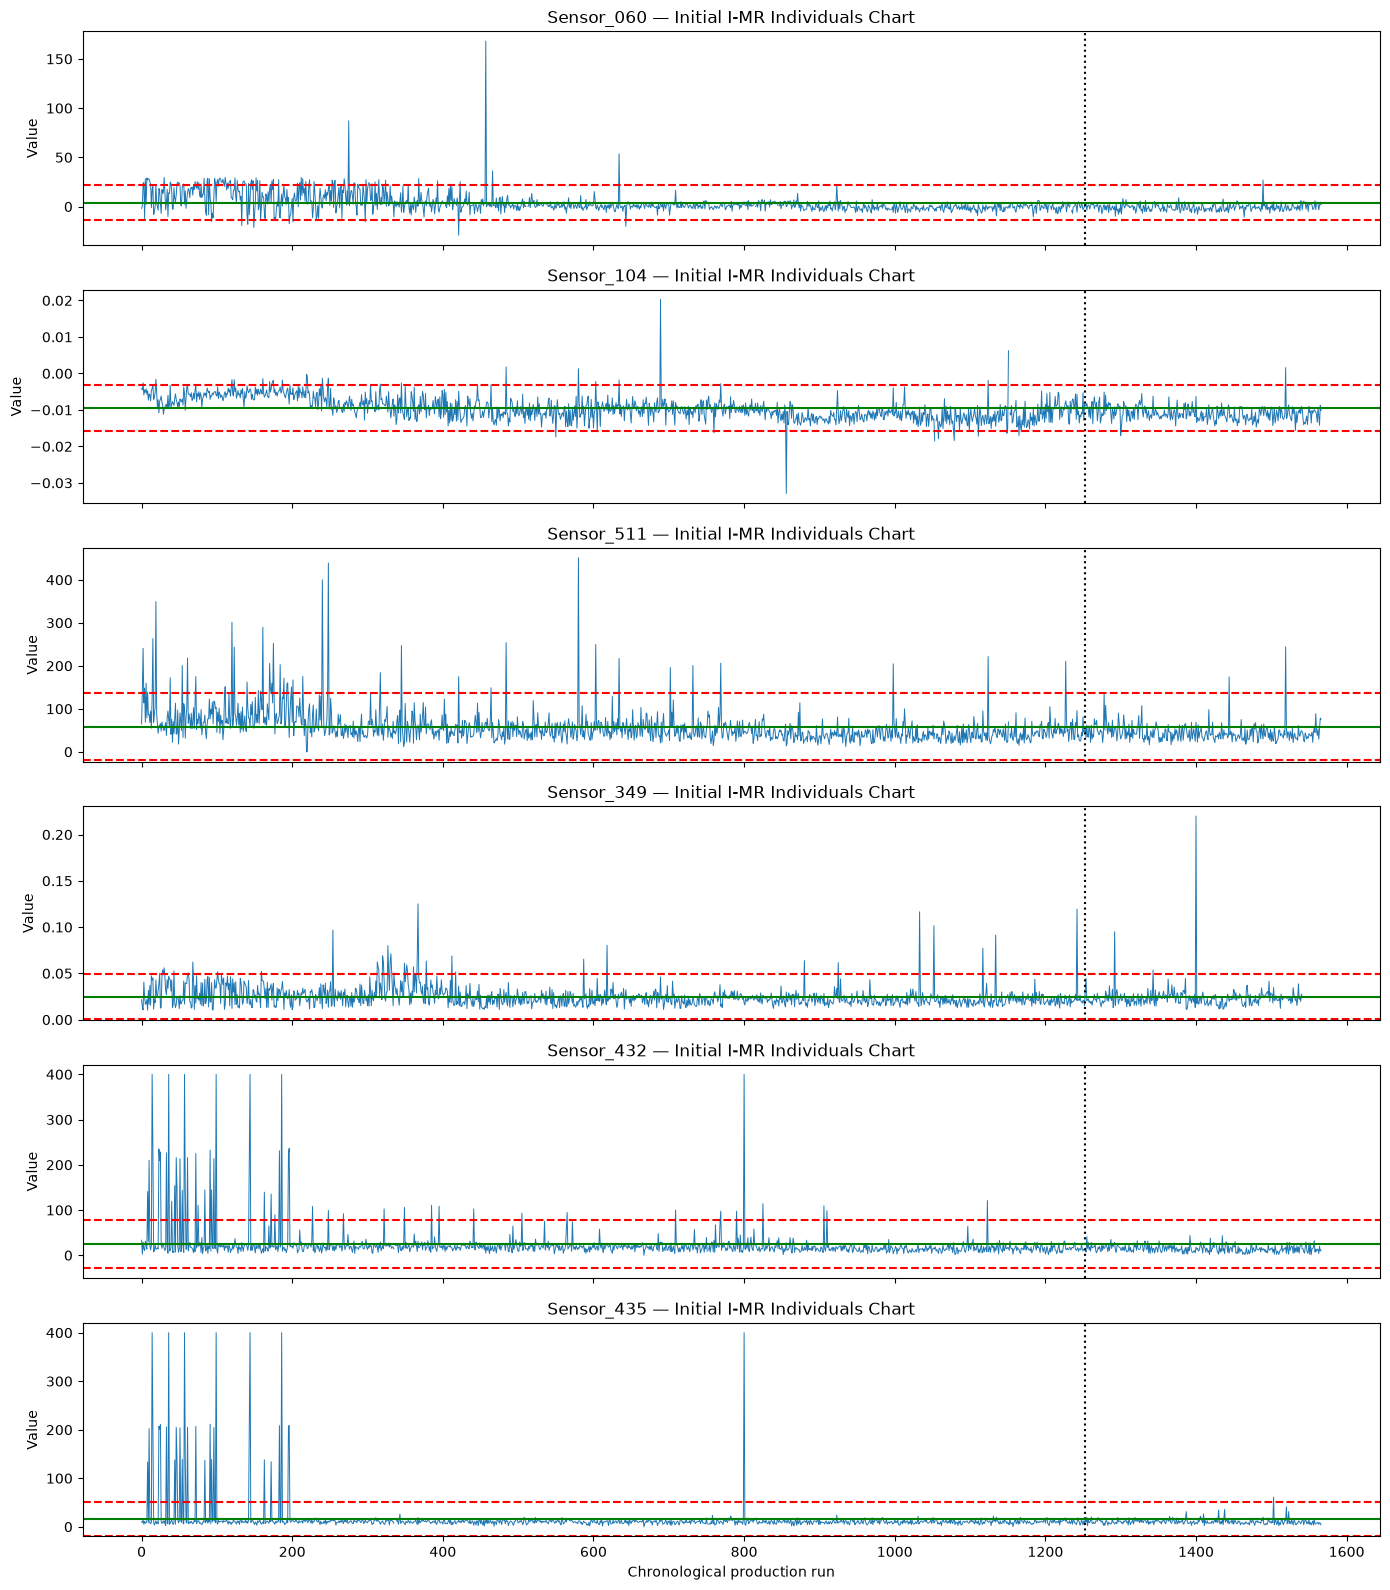

,Baseline_Mean,Estimated_Sigma,LCL,UCL,Signal_Count
Sensor,,,,,
Sensor_060,3.858609,5.912855,-13.879956,21.597174,110
Sensor_104,-0.009508,0.002089,-0.015773,-0.003242,44
Sensor_511,58.544509,25.848480,-19.000931,136.089949,52
Sensor_349,0.024902,0.008014,0.000861,0.048943,44
Sensor_432,24.298243,17.824500,-29.175258,77.771744,52
Sensor_435,15.766540,11.673015,-19.252504,50.785584,33


In [7]:
import matplotlib.pyplot as plt

ordered = secom.sort_values("Timestamp").reset_index(drop=True)

baseline_end = int(len(ordered) * 0.80)
baseline = ordered.iloc[:baseline_end]
monitoring = ordered.iloc[baseline_end:]

D2 = 1.128
control_rows = []

fig, axes = plt.subplots(
    len(top_sensors),
    1,
    figsize=(14, 16),
    sharex=True
)

for ax, sensor in zip(axes, top_sensors):
    baseline_values = baseline[sensor].dropna()

    center = baseline_values.mean()
    moving_range = baseline_values.diff().abs().dropna()
    sigma = moving_range.mean() / D2

    ucl = center + 3 * sigma
    lcl = center - 3 * sigma

    all_values = ordered[sensor]
    signals = (all_values > ucl) | (all_values < lcl)

    control_rows.append({
        "Sensor": sensor,
        "Baseline_Mean": center,
        "Estimated_Sigma": sigma,
        "LCL": lcl,
        "UCL": ucl,
        "Signal_Count": signals.sum(),
    })

    ax.plot(all_values, linewidth=0.7)
    ax.axvline(baseline_end, color="black", linestyle=":")
    ax.axhline(center, color="green", linestyle="-", label="Center")
    ax.axhline(ucl, color="red", linestyle="--", label="Control limits")
    ax.axhline(lcl, color="red", linestyle="--")
    ax.set_title(f"{sensor} — Initial I-MR Individuals Chart")
    ax.set_ylabel("Value")

axes[-1].set_xlabel("Chronological production run")
plt.tight_layout()
plt.show()

control_limits = pd.DataFrame(control_rows).set_index("Sensor")
display(control_limits)

In [8]:
signal_comparison = []

for sensor in top_sensors:
    limits = control_limits.loc[sensor]

    signal = (
        ordered[sensor].gt(limits["UCL"])
        | ordered[sensor].lt(limits["LCL"])
    )

    signal_comparison.append({
        "Sensor": sensor,
        "Total_Signals": int(signal.sum()),
        "Pass_Signal_Rate": signal[~ordered["Failed"]].mean(),
        "Fail_Signal_Rate": signal[ordered["Failed"]].mean(),
        "Failed_Runs_With_Signal": int(
            (signal & ordered["Failed"]).sum()
        ),
        "Total_Failed_Runs": int(ordered["Failed"].sum()),
    })

signal_comparison = pd.DataFrame(signal_comparison)
display(signal_comparison)

,Sensor,Total_Signals,Pass_Signal_Rate,Fail_Signal_Rate,Failed_Runs_With_Signal,Total_Failed_Runs
0,Sensor_060,110,0.064252,0.153846,16,104
1,Sensor_104,44,0.025974,0.057692,6,104
2,Sensor_511,52,0.029392,0.086538,9,104
3,Sensor_349,44,0.025290,0.067308,7,104
4,Sensor_432,52,0.028708,0.096154,10,104
5,Sensor_435,33,0.017772,0.067308,7,104


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

model_data = X[top_sensors].copy()
target = secom["Failed"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    model_data,
    target,
    test_size=0.25,
    stratify=target,
    random_state=42,
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    )),
])

model.fit(X_train, y_train)

predicted = model.predict(X_test)
probability = model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, predicted).ravel()

model_results = pd.DataFrame({
    "Metric": [
        "Balanced accuracy",
        "Precision",
        "Recall",
        "F1 score",
        "ROC-AUC",
        "Average precision",
        "Escape rate",
        "False-reject rate",
    ],
    "Value": [
        balanced_accuracy_score(y_test, predicted),
        precision_score(y_test, predicted),
        recall_score(y_test, predicted),
        f1_score(y_test, predicted),
        roc_auc_score(y_test, probability),
        average_precision_score(y_test, probability),
        fn / (fn + tp),
        fp / (fp + tn),
    ],
})

display(model_results)
print("Confusion matrix:")
print(confusion_matrix(y_test, predicted))

,Metric,Value
0,Balanced accuracy,0.757461
1,Precision,0.193878
2,Recall,0.730769
3,F1 score,0.306452
4,ROC-AUC,0.770807
5,Average precision,0.197778
6,Escape rate,0.269231
7,False-reject rate,0.215847


Confusion matrix:
[[287  79]
 [  7  19]]


In [10]:
coefficients = model.named_steps["classifier"].coef_[0]

model_signal = pd.DataFrame({
    "Sensor": top_sensors,
    "Model_Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients),
})

model_signal["Model_Interpretation"] = np.where(
    model_signal["Model_Coefficient"] > 0,
    "Higher values associated with failure",
    "Higher values associated with passing",
)

comparison = (
    signal_comparison
    .merge(model_signal, on="Sensor")
    .sort_values("Fail_Signal_Rate", ascending=False)
)

display(comparison)

,Sensor,Total_Signals,Pass_Signal_Rate,Fail_Signal_Rate,Failed_Runs_With_Signal,Total_Failed_Runs,Model_Coefficient,Odds_Ratio,Model_Interpretation
0,Sensor_060,110,0.064252,0.153846,16,104,0.325170,1.384266,Higher values associated with failure
4,Sensor_432,52,0.028708,0.096154,10,104,0.235073,1.265001,Higher values associated with failure
2,Sensor_511,52,0.029392,0.086538,9,104,0.122867,1.130734,Higher values associated with failure
3,Sensor_349,44,0.025290,0.067308,7,104,0.193934,1.214017,Higher values associated with failure
5,Sensor_435,33,0.017772,0.067308,7,104,-0.114691,0.891641,Higher values associated with passing
1,Sensor_104,44,0.025974,0.057692,6,104,0.327919,1.388077,Higher values associated with failure


## Part 2 Conclusions

The SECOM dataset contains substantial missingness and many non-informative sensors. Constant sensors were removed, while heavily missing and near-constant sensors were flagged for review.

The selected sensors showed statistically different behavior between passing and failing runs. A class-weighted logistic regression model was evaluated using a stratified train/test split. Performance was assessed using balanced accuracy, Average precision, ROC-AUC, escape rate, and false-reject rate rather than raw accuracy.

The control-chart results and model results identify sensors carrying useful failure signal. However, the signals are statistical associations, not confirmed physical root causes.

## Limitations

- Sensor names and units are anonymized.
- Engineering specification limits are unavailable, so Cp and Cpk cannot be calculated.
- Control limits are statistical monitoring limits, not specification limits.
- Sensor selection was exploratory.
- Correlation and model coefficients do not establish causation.
- The dataset represents one production line and one historical time window.